# Average Performance + Dataset-wise Delta Analysis

Two-panel figure showing:
1. **Left**: Average performance across all datasets for top competing models
2. **Right**: Dataset-wise delta analysis with win statistics and SugarCrepe analysis

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import sys
sys.path.insert(0, '..')  # Add parent directory to path

from evalviz.config import load_runs_from_files, load_methods, load_benchmarks
from evalviz.io import load_results_from_runs
from evalviz.preprocess import apply_mappings, add_dataset_type_columns, apply_dataset_merge_rules
from evalviz.enrich import attach_method_metadata, attach_benchmark_metadata
from evalviz.tables import build_summary_table, build_capability_table
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# Colorblind-friendly palette from Paul Tol
COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

# Model color assignments using colorblind palette
MODEL_COLORS = {
    "CLIP": "#999999",  # Grey for baseline
    "NegCLIP": COLORBLIND_PALETTE[1],  # Orange/Red
    "NegCLIP (COCO)": COLORBLIND_PALETTE[1],
    "CS-CLIP": COLORBLIND_PALETTE[2],  # Green/Teal - our model
    # Colors for other strong competitors
    "DAC (LLM)": COLORBLIND_PALETTE[3],
    "DAC (SAM)": COLORBLIND_PALETTE[4],
    "TSVLC": COLORBLIND_PALETTE[5],
    "TripletCLIP (CC12M)": COLORBLIND_PALETTE[6] if len(COLORBLIND_PALETTE) > 6 else COLORBLIND_PALETTE[0],
    "CLoVe": COLORBLIND_PALETTE[0],
}

# Dataset short names for display
DATASET_SHORT_NAMES = {
    "VL_CheckList": "VLC",
    "VL CheckList": "VLC",
    "SugarCrepe++": "SC++",
    "SugarCrepe": "SC",
    "ControlledImages": "WhatsUp",
    "Controlled Images": "WhatsUp",
}

# Short model names for display
MODEL_SHORT_NAMES = {
    "NegCLIP (COCO)": "NegCLIP",
    "TripletCLIP (CC12M)": "TripletCLIP",
    "DAC (LLM)": "DAC-LLM",
    "DAC (SAM)": "DAC-SAM",
    "FSC CLIP (CC3M)": "FSC",
    "FSC CLIP (COCO)": "FSC-COCO",
    "FSC CLIP (LAION+COCO)": "FSC-L+C",
    "LaCLIP (CC12M)": "LaCLIP",
    "CLIC CogVLM (LAION)": "CLIC-LAION",
    "CLIC CogVLM (PixPR RedCaps)": "CLIC-PixPR",
}

In [4]:
# Load data from evalviz
ours = "../configs/runs_ours_final.json"

runs = load_runs_from_files(
    "../configs/runs_baselines.json",
    "../configs/runs_external.json",
    ours
)

methods = load_methods("../configs/methods.json")
bench_cfg = load_benchmarks("../configs/benchmarks.json")

df = load_results_from_runs(runs)
df = apply_dataset_merge_rules(df, bench_cfg)
df = apply_mappings(df, bench_cfg)
df = add_dataset_type_columns(df)
df = attach_method_metadata(df, methods)
df = attach_benchmark_metadata(df, bench_cfg)

# Build dataset summary table
dataset_table, _ = build_summary_table(df)

print(f"Available models: {list(dataset_table.index)}")
print(f"Available datasets: {list(dataset_table.columns)}")

[apply_mappings] Dropped 38 original rows replaced by aliased metrics
Available models: ['CE CLIP', 'CLIC CogVLM (LAION)', 'CLIC CogVLM (PixPR RedCaps)', 'CLIP', 'CLoVe', 'CON CLIP', 'CS-CLIP', 'DAC (LLM)', 'DAC (SAM)', 'DeGLA', 'FSC CLIP (CC3M)', 'FSC CLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'LaCLIP (CC12M)', 'LabCLIP', 'NegCLIP (COCO)', 'READCLIP', 'TSVLC', 'TripletCLIP (CC12M)']
Available datasets: ['ARO', 'BLA', 'COCO-CF', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VL_CheckList', 'VisMin', 'Winoground']


In [5]:
# =============================================================================
# DATA PREPARATION
# =============================================================================

# Setup tueplots for DOUBLE-column ICML figure
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black", 
    "xtick.color": "black",
    "ytick.color": "black",
})

# =============================================================================
# Configuration
# =============================================================================

baseline_model = "CLIP"
negclip_model = "NegCLIP (COCO)" if "NegCLIP (COCO)" in dataset_table.index else "NegCLIP"
csclip_model = "CS-CLIP"

def get_short_label(name, name_map=DATASET_SHORT_NAMES):
    """Get short display name."""
    return name_map.get(name, name)

def get_model_short_name(model):
    """Get short display name for model."""
    return MODEL_SHORT_NAMES.get(model, model)

# =============================================================================
# Compute Average Performance for All Models
# =============================================================================

all_datasets = list(dataset_table.columns)
n_datasets = len(all_datasets)

# Compute average performance for ALL models
avg_perf_all = {}
for model in dataset_table.index:
    vals = dataset_table.loc[model] * 100
    if not vals.isna().all():
        avg_perf_all[model] = vals.mean()

# Sort models by average performance (descending)
sorted_models = sorted(avg_perf_all.keys(), key=lambda m: avg_perf_all[m], reverse=True)

print("="*70)
print("ALL MODELS RANKED BY AVERAGE PERFORMANCE")
print("="*70)
for i, model in enumerate(sorted_models):
    marker = " ★" if model == csclip_model else ("" if model != baseline_model else " (baseline)")
    print(f"{i+1:2d}. {model:35s}: {avg_perf_all[model]:.2f}%{marker}")

# =============================================================================
# Select Top Models for Average Performance Panel
# =============================================================================

# We want: CLIP (baseline), CS-CLIP (ours), and top 4-6 other competitors
n_top_others = 5  # Number of competitors besides CLIP and CS-CLIP

# Get top competitors (excluding CLIP and CS-CLIP)
top_competitors = [m for m in sorted_models if m not in [baseline_model, csclip_model]][:n_top_others]

# Build final model list for average performance panel: CLIP, top competitors, CS-CLIP
avg_panel_models = [baseline_model] + top_competitors + [csclip_model]
avg_panel_models = [m for m in avg_panel_models if m in avg_perf_all]  # Filter available

print(f"\nModels selected for average performance panel: {avg_panel_models}")

# =============================================================================
# Compute Deltas and Win Statistics
# =============================================================================

# Get model values in percentage
model_values = {m: dataset_table.loc[m] * 100 for m in dataset_table.index}
baseline_values = model_values[baseline_model]

# Compute deltas for comparison models (NegCLIP and CS-CLIP)
compare_models = [negclip_model, csclip_model]
delta_data = {}
for model in compare_models:
    if model in model_values:
        delta_data[model] = model_values[model] - baseline_values

# Sort datasets by CS-CLIP improvement (descending)
sorted_datasets = sorted(all_datasets, key=lambda ds: delta_data[csclip_model][ds], reverse=True)

# =============================================================================
# Win Statistics: Dataset-wise rankings
# =============================================================================

print("\n" + "="*70)
print("WIN STATISTICS")
print("="*70)

# Count wins per model (where model beats CLIP)
wins_vs_clip = {}
for model in dataset_table.index:
    if model == baseline_model:
        continue
    wins = sum(1 for ds in all_datasets 
               if model_values[model][ds] > baseline_values[ds])
    wins_vs_clip[model] = wins

# Count wins per dataset (which model is best)
dataset_winners = {}
for ds in all_datasets:
    best_model = max(dataset_table.index, key=lambda m: dataset_table.loc[m, ds])
    dataset_winners[ds] = best_model

# Count how often each model wins
model_wins = {m: 0 for m in dataset_table.index}
for ds, winner in dataset_winners.items():
    model_wins[winner] += 1

print(f"\nWins per model (best performer on each dataset):")
for model, wins in sorted(model_wins.items(), key=lambda x: -x[1]):
    if wins > 0:
        print(f"  {model:35s}: {wins}/{n_datasets} datasets")

# Count times CS-CLIP beats each competitor
print(f"\nCS-CLIP vs each competitor (head-to-head wins):")
for model in sorted_models:
    if model == csclip_model:
        continue
    csclip_wins = sum(1 for ds in all_datasets 
                      if model_values[csclip_model][ds] > model_values[model][ds])
    print(f"  vs {model:35s}: {csclip_wins}/{n_datasets} ({100*csclip_wins/n_datasets:.0f}%)")

# =============================================================================
# SugarCrepe Analysis  
# =============================================================================

print("\n" + "="*70)
print("SUGARCREPE ANALYSIS")
print("="*70)

# Check for SugarCrepe datasets
sugarcrepe_datasets = [ds for ds in all_datasets if 'SugarCrepe' in ds or 'Sugar' in ds]
print(f"SugarCrepe-related datasets: {sugarcrepe_datasets}")

# Detailed SugarCrepe performance
for ds in sugarcrepe_datasets:
    print(f"\n{ds}:")
    ds_perf = [(m, model_values[m][ds]) for m in dataset_table.index]
    ds_perf.sort(key=lambda x: -x[1])
    for i, (model, perf) in enumerate(ds_perf[:5]):  # Top 5
        marker = " ★" if model == csclip_model else ""
        print(f"  {i+1}. {model:35s}: {perf:.2f}%{marker}")

# CS-CLIP rank on SugarCrepe datasets
csclip_sugarcrepe_ranks = {}
for ds in sugarcrepe_datasets:
    ds_perf = [(m, model_values[m][ds]) for m in dataset_table.index]
    ds_perf.sort(key=lambda x: -x[1])
    rank = next(i+1 for i, (m, _) in enumerate(ds_perf) if m == csclip_model)
    csclip_sugarcrepe_ranks[ds] = rank

print(f"\nCS-CLIP ranks on SugarCrepe datasets: {csclip_sugarcrepe_ranks}")

ALL MODELS RANKED BY AVERAGE PERFORMANCE
 1. CS-CLIP                            : 57.84% ★
 2. FSC CLIP (COCO)                    : 57.42%
 3. READCLIP                           : 56.89%
 4. DeGLA                              : 56.20%
 5. FSC CLIP (CC3M)                    : 55.53%
 6. NegCLIP (COCO)                     : 55.34%
 7. CLoVe                              : 55.06%
 8. FSC CLIP (LAION+COCO)              : 54.97%
 9. CLIC CogVLM (PixPR RedCaps)        : 54.53%
10. CE CLIP                            : 54.38%
11. CLIC CogVLM (LAION)                : 54.34%
12. LabCLIP                            : 54.16%
13. DAC (LLM)                          : 52.20%
14. CLIP                               : 52.08% (baseline)
15. DAC (SAM)                          : 51.72%
16. TSVLC                              : 51.66%
17. CON CLIP                           : 51.16%
18. TripletCLIP (CC12M)                : 44.61%
19. LaCLIP (CC12M)                     : 42.79%

Models selected for average perfo

/tmp/ipykernel_1885198/2795132030.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1885198/2795132030.py:220: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


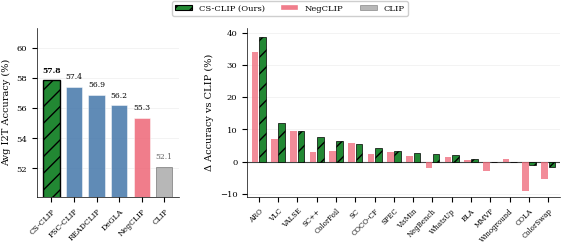

In [16]:
# =============================================================================
# Create Two-Panel Figure with Enhanced Statistics
# =============================================================================

# Setup tueplots properly for ICML double-column
from tueplots import figsizes, fontsizes, fonts

plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())
plt.rcParams.update(fonts.icml2024_tex())
plt.rcParams.update({
    "text.usetex": False,  # Disable if LaTeX not available
    "text.color": "black",
    "axes.labelcolor": "black", 
    "xtick.color": "black",
    "ytick.color": "black",
})

fig_width = plt.rcParams["figure.figsize"][0]  # Use tueplots width
fig_height = 2.2  # Single row, compact

fig = plt.figure(figsize=(fig_width, fig_height))

# GridSpec: 1 row, 2 columns
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 2.2], wspace=0.30)

ax_avg = fig.add_subplot(gs[0])
ax_delta = fig.add_subplot(gs[1])

# =============================================================================
# Consistent Color scheme (matching comp_benchmarks_figures.ipynb)
# =============================================================================

# Use consistent colors across both notebooks
CONSISTENT_COLORS = {
    "CLIP": "#999999",  # Grey for baseline
    "NegCLIP": COLORBLIND_PALETTE[1],  # Orange/Red
    "NegCLIP (COCO)": COLORBLIND_PALETTE[1],
    "CS-CLIP": COLORBLIND_PALETTE[2],  # Green/Teal - our model
}

# Color for all other external models (not CLIP, NegCLIP, or CS-CLIP)
EXTERNAL_MODEL_COLOR = COLORBLIND_PALETTE[0]  # Blue - same for all external

def get_model_color(model):
    """Get color for a model, with special handling."""
    if model in CONSISTENT_COLORS:
        return CONSISTENT_COLORS[model]
    # All other external models get the same color
    return EXTERNAL_MODEL_COLOR

# =============================================================================
# LEFT PANEL: Average Performance Bar Chart
# Show CLIP, NegCLIP, 3 external models, and CS-CLIP
# =============================================================================

# Select models: CLIP, NegCLIP, CS-CLIP, and exactly 3 top external competitors
excluded_models = [baseline_model, csclip_model, negclip_model, "FSC CLIP (CC3M)", "FSC CLIP (LAION+COCO)"]
external_competitors = [m for m in sorted_models if m not in excluded_models][:3]

# Build final model list: CLIP, NegCLIP, 3 external competitors, CS-CLIP
avg_panel_models = [baseline_model, negclip_model] + external_competitors + [csclip_model]
avg_panel_models = [m for m in avg_panel_models if m in avg_perf_all]  # Filter available

# Sort by performance (descending = best first)
avg_panel_models_sorted = sorted(avg_panel_models, key=lambda m: avg_perf_all[m], reverse=True)

# Update MODEL_SHORT_NAMES to show FSC-CLIP instead of FSC-COCO
MODEL_SHORT_NAMES["FSC CLIP (COCO)"] = "FSC-CLIP"

n_models_avg = len(avg_panel_models_sorted)
x_pos_avg = np.arange(n_models_avg)
bar_width_avg = 0.72

for i, model in enumerate(avg_panel_models_sorted):
    val = avg_perf_all[model]
    color = get_model_color(model)
    display_name = get_model_short_name(model)
    
    # Special styling for CS-CLIP (ours)
    if model == csclip_model:
        ax_avg.bar(i, val, width=bar_width_avg, color=color, 
                   edgecolor='black', linewidth=1.0, hatch='//', 
                   alpha=1.0, zorder=10, label="CS-CLIP*")
        fontweight = 'bold'
        fontcolor = 'black'
    elif model == baseline_model:
        ax_avg.bar(i, val, width=bar_width_avg, color=color, 
                   edgecolor='#666666', linewidth=0.6, 
                   alpha=0.7, zorder=5, label="CLIP")
        fontweight = 'normal'
        fontcolor = '#666666'
    elif model == negclip_model:
        ax_avg.bar(i, val, width=bar_width_avg, color=color, 
                   edgecolor='white', linewidth=0.4, 
                   alpha=0.85, zorder=5, label="NegCLIP")
        fontweight = 'normal'
        fontcolor = 'black'
    else:
        # External models - all same color
        ax_avg.bar(i, val, width=bar_width_avg, color=color, 
                   edgecolor='white', linewidth=0.4, 
                   alpha=0.85, zorder=5)
        fontweight = 'normal'
        fontcolor = 'black'
    
    # Value label on top of bar
    ax_avg.text(i, val + 0.4, f'{val:.1f}', ha='center', va='bottom', 
                fontsize=5.5, fontweight=fontweight, color=fontcolor)

# X-axis labels
ax_avg.set_xticks(x_pos_avg)
xticklabels = []
for m in avg_panel_models_sorted:
    label = get_model_short_name(m)
    if m == csclip_model:
        label = label
    xticklabels.append(label)
ax_avg.set_xticklabels(xticklabels, fontsize=5.5, rotation=45, ha='right', rotation_mode='anchor')

# Y-axis
ax_avg.set_ylabel('Avg I2T Accuracy (%)', fontsize=7)
y_min_avg = min(avg_perf_all[m] for m in avg_panel_models_sorted) - 2
y_max_avg = max(avg_perf_all[m] for m in avg_panel_models_sorted) + 3.5
ax_avg.set_ylim(y_min_avg, y_max_avg)

# Grid and spines
ax_avg.yaxis.grid(True, linestyle='-', alpha=0.2, linewidth=0.5, zorder=0)
ax_avg.set_axisbelow(True)
ax_avg.spines['top'].set_visible(False)
ax_avg.spines['right'].set_visible(False)
ax_avg.spines['left'].set_linewidth(0.5)
ax_avg.spines['bottom'].set_linewidth(0.5)

# =============================================================================
# RIGHT PANEL: Dataset-wise Delta Grouped Bar Chart
# =============================================================================

x_positions = np.arange(n_datasets)
n_compare = len(compare_models)
bar_width = 0.38

# Zero line
ax_delta.axhline(y=0, color='#444444', linewidth=0.8, linestyle='-', zorder=2)

# Model display settings - use consistent colors
delta_model_colors = {
    negclip_model: CONSISTENT_COLORS.get("NegCLIP (COCO)", COLORBLIND_PALETTE[1]),
    csclip_model: CONSISTENT_COLORS.get("CS-CLIP", COLORBLIND_PALETTE[2]),
}

delta_model_hatches = {
    negclip_model: "",
    csclip_model: "//",
}

# Draw grouped bars
for model_idx, model in enumerate(compare_models):
    deltas = [delta_data[model][ds] for ds in sorted_datasets]
    color = delta_model_colors.get(model, COLORBLIND_PALETTE[0])
    hatch = delta_model_hatches.get(model, "")
    display_name = get_model_short_name(model)
    
    x_offset = (model_idx - (n_compare - 1) / 2) * bar_width
    x_pos = x_positions + x_offset
    
    # Keep same color for all bars (positive or negative)
    if model == csclip_model:
        bars = ax_delta.bar(x_pos, deltas, width=bar_width * 0.9, color=color, 
                            edgecolor='black', linewidth=0.5, hatch=hatch,
                            alpha=1.0, zorder=10, label=f"{display_name}")
    else:
        bars = ax_delta.bar(x_pos, deltas, width=bar_width * 0.9, color=color, 
                            alpha=0.75, zorder=5, label=display_name)
       
# X-axis: Dataset names
formatted_labels = [get_short_label(ds) for ds in sorted_datasets]
ax_delta.set_xticks(x_positions)
ax_delta.set_xticklabels(formatted_labels, fontsize=5, rotation=45, ha='right', rotation_mode='anchor')
ax_delta.set_xlim(-0.6, n_datasets - 0.4)

# Y-axis - reduced max since no annotations
ax_delta.set_ylabel('Δ Accuracy vs CLIP (%)', fontsize=7)
all_deltas_flat = [d for model_deltas in delta_data.values() for d in model_deltas.values]
y_min_delta = min(all_deltas_flat) - 2
y_max_delta = max(all_deltas_flat) + 3  # Less space needed without annotations
ax_delta.set_ylim(y_min_delta, y_max_delta)

# Grid and spines
ax_delta.yaxis.grid(True, linestyle='-', alpha=0.2, linewidth=0.5, zorder=0)
ax_delta.set_axisbelow(True)
ax_delta.spines['top'].set_visible(False)
ax_delta.spines['right'].set_visible(False)
ax_delta.spines['left'].set_linewidth(0.5)
ax_delta.spines['bottom'].set_linewidth(0.5)

# =============================================================================
# Common Legend for both panels (placed at top or between panels)
# =============================================================================

# Create custom legend handles with consistent styling
legend_handles = [
    mpatches.Patch(facecolor=CONSISTENT_COLORS["CS-CLIP"], edgecolor='black', 
                   linewidth=0.8, hatch='//', label='CS-CLIP (Ours)'),
    mpatches.Patch(facecolor=CONSISTENT_COLORS["NegCLIP (COCO)"], edgecolor='white', 
                   linewidth=0.3, alpha=0.85, label='NegCLIP'),
    mpatches.Patch(facecolor=CONSISTENT_COLORS["CLIP"], edgecolor='#666666', 
                   linewidth=0.5, alpha=0.7, label='CLIP'),
]

# Place common legend at top of figure
fig.legend(handles=legend_handles, loc='upper center', ncol=4, 
           fontsize=6, frameon=True, framealpha=0.95,
           bbox_to_anchor=(0.5, 1.02))

# =============================================================================
# Final Layout and Save
# =============================================================================

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Make room for legend

# Save figures
import os
os.makedirs('../paper_figures', exist_ok=True)
plt.savefig('../paper_figures/avg_and_delta_analysis.pdf', bbox_inches='tight', dpi=300)
plt.savefig('../paper_figures/avg_and_delta_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

In [11]:
# =============================================================================
# DETAILED COMPARISON TABLE
# =============================================================================

print("="*90)
print("HEAD-TO-HEAD COMPARISON: CS-CLIP vs All Competitors")
print("="*90)

# Create comparison dataframe
comparison_rows = []
for model in sorted_models:
    if model == csclip_model:
        continue
    
    # Count wins on each dataset
    csclip_better = 0
    model_better = 0
    ties = 0
    
    for ds in all_datasets:
        csclip_val = model_values[csclip_model][ds]
        model_val = model_values[model][ds]
        
        if csclip_val > model_val:
            csclip_better += 1
        elif model_val > csclip_val:
            model_better += 1
        else:
            ties += 1
    
    # Avg performance comparison
    csclip_avg = avg_perf_all[csclip_model]
    model_avg = avg_perf_all[model]
    avg_diff = csclip_avg - model_avg
    
    comparison_rows.append({
        'Competitor': get_model_short_name(model),
        'Competitor Avg': f'{model_avg:.1f}%',
        'CS-CLIP Wins': csclip_better,
        'Competitor Wins': model_better,
        'Ties': ties,
        'Avg Δ': f'{avg_diff:+.1f}%',
        'Win Rate': f'{100*csclip_better/n_datasets:.0f}%'
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

# Summary statistics
total_comparisons = len(comparison_rows) * n_datasets
total_cs_wins = sum(row['CS-CLIP Wins'] for row in comparison_rows)
total_comp_wins = sum(row['Competitor Wins'] for row in comparison_rows)

print(f"\n{'='*90}")
print(f"AGGREGATE STATISTICS")
print(f"{'='*90}")
print(f"Total pairwise comparisons: {total_comparisons}")
print(f"CS-CLIP wins: {total_cs_wins} ({100*total_cs_wins/total_comparisons:.1f}%)")
print(f"Competitor wins: {total_comp_wins} ({100*total_comp_wins/total_comparisons:.1f}%)")
print(f"CS-CLIP overall ranking: #{csclip_rank}/{len(sorted_models)} by average performance")

HEAD-TO-HEAD COMPARISON: CS-CLIP vs All Competitors
 Competitor Competitor Avg  CS-CLIP Wins  Competitor Wins  Ties  Avg Δ Win Rate
   FSC-CLIP          57.4%             9                7     0  +0.4%      56%
   READCLIP          56.9%             9                7     0  +0.9%      56%
      DeGLA          56.2%            11                5     0  +1.6%      69%
        FSC          55.5%            13                3     0  +2.3%      81%
    NegCLIP          55.3%            14                2     0  +2.5%      88%
      CLoVe          55.1%            12                3     1  +2.8%      75%
    FSC-L+C          55.0%            14                2     0  +2.9%      88%
 CLIC-PixPR          54.5%            13                3     0  +3.3%      81%
    CE CLIP          54.4%            11                5     0  +3.5%      69%
 CLIC-LAION          54.3%            14                2     0  +3.5%      88%
    LabCLIP          54.2%            16                0     0  +3.

NameError: name 'csclip_rank' is not defined